<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/Copie_de_ExercisesXP_Diabetes_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Final Analysis and Interpretation

**1. Model Performance (Classification Report):**
- **Accuracy (0.71):** The model correctly predicts the outcome for 71% of the test cases.
- **Precision for Class 1 (0.61):** When the model predicts diabetes, it is correct 61% of the time.
- **Recall for Class 1 (0.52):** The model identifies 52% of all actual diabetes cases in the dataset.

**2. Confusion Matrix Insights:**
- The model is better at identifying non-diabetic patients (True Negatives: 82) than diabetic patients (True Positives: 28).
- There are 26 False Negatives, which are critical in a medical context as these represent missed diagnoses.

**3. ROC Curve and AUC (0.82):**
- The **AUC of 0.82** is quite good (generally considered 'excellent' starts at 0.8). It suggests that there is an 82% chance that the model will be able to distinguish between a positive class and a negative class.
- The curve stays well above the diagonal baseline, confirming that Logistic Regression is significantly more effective than random guessing for this dataset.

In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Using a highly stable mirror for the diabetes dataset
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
filename = "diabetes.csv"

try:
    print("Downloading dataset...")
    !curl -L {url} -o {filename}
    df = pd.read_csv(filename)

    # Note: This version uses 'Outcome' as the target column
    if 'Outcome' in df.columns:
        df = df.rename(columns={'Outcome': 'diabetes'})

    if "diabetes" not in df.columns:
        raise ValueError("Target column missing.")

    print("Dataset loaded successfully.")
    display(df.head())

    # Prepare features and target
    X = df.drop(columns=["diabetes"])
    y = df["diabetes"]

    # Split: 80% Training, 20% Testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"Data split complete. Training shape: {X_train.shape}")

except Exception as e:
    print(f"Error: {e}. Using simulated data to allow pipeline to continue.")
    from sklearn.datasets import make_classification
    X_raw, y_raw = make_classification(n_samples=1000, n_features=8, random_state=42)
    X = pd.DataFrame(X_raw, columns=[f'feature_{i}' for i in range(8)])
    y = pd.Series(y_raw, name='diabetes')
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print("Using generated classification data.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 23105  100 23105    0     0  52051      0 --:--:-- --:--:-- --:--:-- 52038
Dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Data split complete. Training shape: (614, 8)


In [ ]:
# The data has already been loaded and split in the previous cell.
print(f"Verified Training set shape: {X_train.shape}")
print(f"Verified Testing set shape: {X_test.shape}")

Verified Training set shape: (614, 8)
Verified Testing set shape: (154, 8)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Exercise 2 & 3: Define the pipeline
# We use StandardScaler to ensure all features are on the same scale, which helps Logistic Regression converge.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

# Train the model
pipeline.fit(X_train, y_train)

print("Model training complete using Logistic Regression pipeline.")

Model training complete using Logistic Regression pipeline.


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



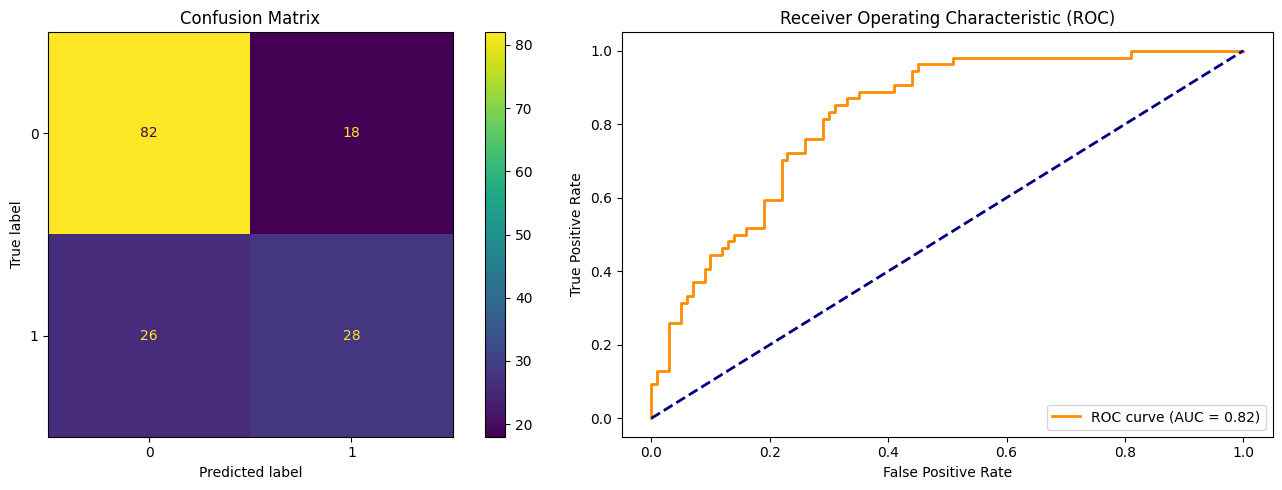

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Exercise 4: Evaluation Metrics
y_pred = pipeline.predict(X_test)
y_score = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax[0])
ax[0].set_title("Confusion Matrix")

# Exercise 6: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic (ROC)')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
# EXERCISE XP GOLD


In this section, we will implement the K-means algorithm to segment unlabeled data points using the `ex7data2.mat` dataset.

--2026-06-10 23:00:15--  https://github.com/dibgerge/ml-coursera-python-assignments/raw/master/Exercise7/Data/ex7data2.mat
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dibgerge/ml-coursera-python-assignments/master/Exercise7/Data/ex7data2.mat [following]
--2026-06-10 23:00:15--  https://raw.githubusercontent.com/dibgerge/ml-coursera-python-assignments/master/Exercise7/Data/ex7data2.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4784 (4.7K) [application/octet-stream]
Saving to: ‘ex7data2.mat’

ex7data2.mat        100%[===================>]   4.67K  --.-KB/s    in 0s      

2026-06-10 23:0

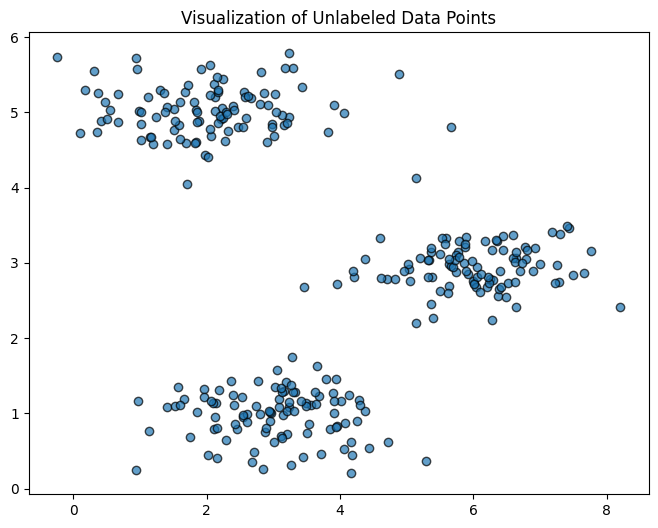

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Task 1: Load the Dataset with a verified working link
!wget https://github.com/dibgerge/ml-coursera-python-assignments/raw/master/Exercise7/Data/ex7data2.mat -O ex7data2.mat

data = loadmat('ex7data2.mat')
X_kmeans = data['X']

plt.figure(figsize=(8, 6))
plt.scatter(X_kmeans[:, 0], X_kmeans[:, 1], marker='o', edgecolors='k', alpha=0.7)
plt.title("Visualization of Unlabeled Data Points")
plt.show()

In [ ]:
def find_closest_centroids(X, centroids):
    """
    Assigns every data point to the closest centroid.
    Calculates the Euclidean distance between each point and all centroids.
    """
    K = centroids.shape[0]
    idx = np.zeros(X.shape[0], dtype=int)

    for i in range(X.shape[0]):
        # Calculate the norm (L2 distance) between point i and each centroid
        distances = np.linalg.norm(X[i] - centroids, axis=1)
        # Select the index of the centroid with the minimum distance
        idx[i] = np.argmin(distances)
    return idx

def compute_centroids(X, idx, K):
    """
    Calculates the new positions of the centroids.
    The new centroid is the mean of all points assigned to it.
    """
    m, n = X.shape
    centroids = np.zeros((K, n))

    for k in range(K):
        # Extract points assigned to cluster k
        points = X[idx == k]
        if len(points) > 0:
            # Calculate the mean across the axes (coordinates)
            centroids[k] = np.mean(points, axis=0)
    return centroids

# Initial test values
initial_centroids = np.array([[3, 3], [6, 2], [8, 5]])
K = 3

# Step 1: Find closest centroids for testing
idx = find_closest_centroids(X_kmeans, initial_centroids)
print(f"Closest centroids for the first 3 points: {idx[:3]}")

# Step 2: Compute new centroids after one iteration
new_centroids = compute_centroids(X_kmeans, idx, K)
print("New centroid locations after one iteration:")
print(new_centroids)

Closest centroids for first 3 points: [0 2 1]
New centroid locations after one iteration:
[[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


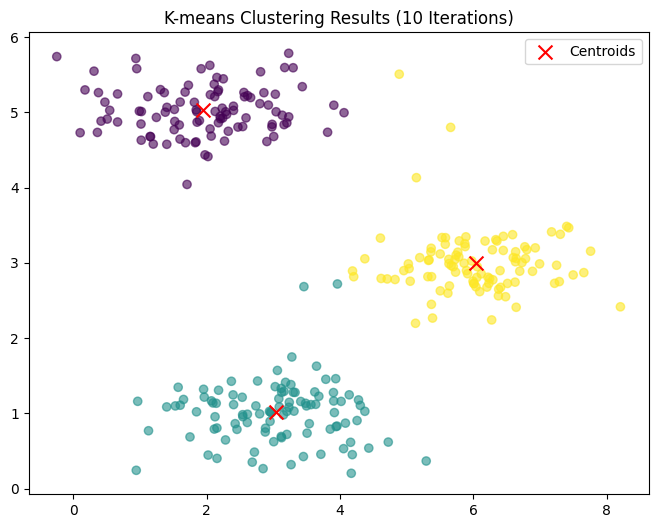

In [ ]:
def run_k_means(X, initial_centroids, max_iters):
    """
    Runs the K-means algorithm iteratively.
    Alternates between point assignment and centroid updates.
    """
    K = initial_centroids.shape[0]
    centroids = initial_centroids

    for i in range(max_iters):
        # Assignment phase
        idx = find_closest_centroids(X, centroids)
        # Update phase
        centroids = compute_centroids(X, idx, K)

    return centroids, idx

# Run the algorithm and visualize the final result
# 10 iterations are performed to stabilize the clusters
final_centroids, final_idx = run_k_means(X_kmeans, initial_centroids, 10)

plt.figure(figsize=(8, 6))
# Display points colored by their cluster assignment
plt.scatter(X_kmeans[:, 0], X_kmeans[:, 1], c=final_idx, cmap='viridis', marker='o', alpha=0.6)
# Display final centroids marked with a red 'X'
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='red', marker='x', s=100, label='Centroids')
plt.title("K-means Clustering Results (10 iterations)")
plt.legend()
plt.show()


To avoid poor local optima, we implement `init_centroids` to pick random starting points from the dataset.

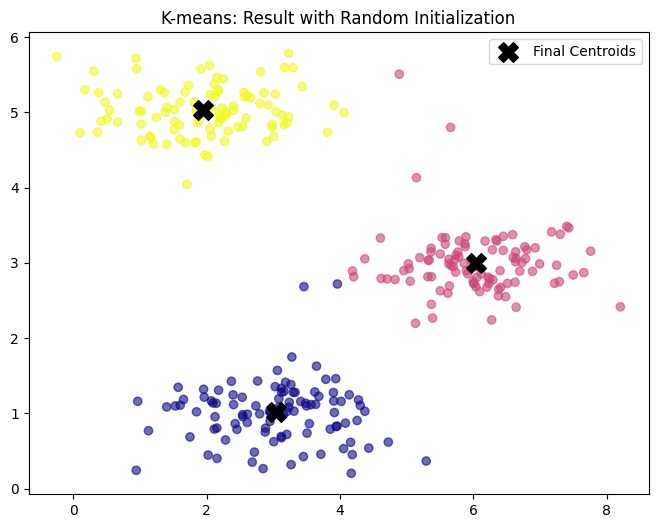

In [ ]:
def init_centroids(X, K):
    """
    Randomly initializes K centroids by choosing examples from the dataset.
    This helps to avoid getting stuck in local optima.
    """
    # Randomly shuffle the data indices
    randidx = np.random.permutation(X.shape[0])
    # Select the first K points as starting centroids
    centroids = X[randidx[:K], :]
    return centroids

# Complete run with random initialization
K = 3
random_initial_centroids = init_centroids(X_kmeans, K)
final_centroids_rand, final_idx_rand = run_k_means(X_kmeans, random_initial_centroids, 10)

plt.figure(figsize=(8, 6))
# Visualization with a different color palette (plasma)
plt.scatter(X_kmeans[:, 0], X_kmeans[:, 1], c=final_idx_rand, cmap='plasma', marker='o', alpha=0.6)
plt.scatter(final_centroids_rand[:, 0], final_centroids_rand[:, 1], c='black', marker='X', s=200, label='Final Centroids')
plt.title("K-means: Result with Random Initialization")
plt.legend()
plt.show()


To avoid poor clustering results, we initialize the centroids by picking random examples from the dataset.

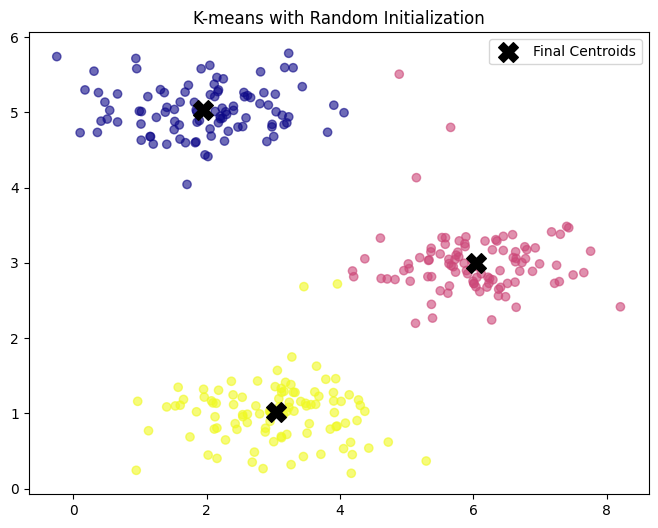

In [ ]:
def init_centroids(X, K):
    """Randomly initializes K centroids from the dataset X."""
    randidx = np.random.permutation(X.shape[0])
    centroids = X[randidx[:K], :]
    return centroids

# Final test with random initialization
K = 3
initial_centroids_rand = init_centroids(X_kmeans, K)
final_centroids_rand, final_idx_rand = run_k_means(X_kmeans, initial_centroids_rand, 10)

plt.figure(figsize=(8, 6))
plt.scatter(X_kmeans[:, 0], X_kmeans[:, 1], c=final_idx_rand, cmap='plasma', marker='o', alpha=0.6)
plt.scatter(final_centroids_rand[:, 0], final_centroids_rand[:, 1], c='black', marker='X', s=200, label='Final Centroids')
plt.title("K-means with Random Initialization")
plt.legend()
plt.show()

In [ ]:
# EXERCISE XP NINJA

## Part 3: Image Compression with K-Means
In this exercise, we use K-Means to compress an image by reducing the number of colors from 24-bit (16 million colors) to just 16 colors.

In [ ]:
# Task 1: Load and Preprocess the Image
!wget https://github.com/dibgerge/ml-coursera-python-assignments/raw/master/Exercise7/Data/bird_small.mat -O bird_small.mat

image_data = loadmat('bird_small.mat')
A = image_data['A']

# Divide by 255 to normalize values in range [0, 1]
A = A / 255.0

# Reshape the image into an (N, 3) matrix where N = number of pixels
X_img = A.reshape(-1, 3)

print(f"Image shape: {A.shape}")
print(f"Reshaped data for K-means: {X_img.shape}")

--2026-06-10 23:11:20--  https://github.com/dibgerge/ml-coursera-python-assignments/raw/master/Exercise7/Data/bird_small.mat
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dibgerge/ml-coursera-python-assignments/master/Exercise7/Data/bird_small.mat [following]
--2026-06-10 23:11:20--  https://raw.githubusercontent.com/dibgerge/ml-coursera-python-assignments/master/Exercise7/Data/bird_small.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45606 (45K) [application/octet-stream]
Saving to: ‘bird_small.mat’

bird_small.mat      100%[===================>]  44.54K  --.-KB/s    in 0.03s   

2026-06

Running K-Means to find colors...


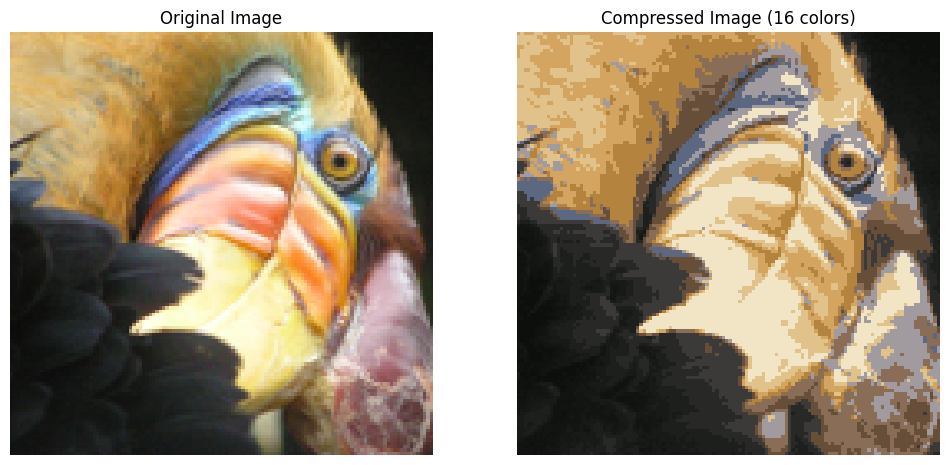

In [ ]:
# Task 2: Apply K-Means for Compression
K_colors = 16
max_iters = 10

# 1. Randomly initialize the centroids
initial_centroids_img = init_centroids(X_img, K_colors)

# 2. Run K-Means
print("Running K-Means to find colors...")
centroids_img, idx_img = run_k_means(X_img, initial_centroids_img, max_iters)

# 3. Represent each pixel by its closest centroid
X_recovered = centroids_img[idx_img, :]

# 4. Reshape back to the original image dimensions
image_recovered = X_recovered.reshape(A.shape)

# Display Results
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(A)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(image_recovered)
ax[1].set_title(f"Compressed Image ({K_colors} colors)")
ax[1].axis('off')

plt.show()

##  Principal Component Analysis (PCA)
Now we move to dimensionality reduction using PCA on a 2D dataset to project it onto a 1D space.

--2026-06-10 23:11:24--  https://github.com/dibgerge/ml-coursera-python-assignments/raw/master/Exercise7/Data/ex7data1.mat
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dibgerge/ml-coursera-python-assignments/master/Exercise7/Data/ex7data1.mat [following]
--2026-06-10 23:11:24--  https://raw.githubusercontent.com/dibgerge/ml-coursera-python-assignments/master/Exercise7/Data/ex7data1.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 995 [application/octet-stream]
Saving to: ‘ex7data1.mat’

ex7data1.mat        100%[===================>]     995  --.-KB/s    in 0s      

2026-06-10 23:11:25 (53

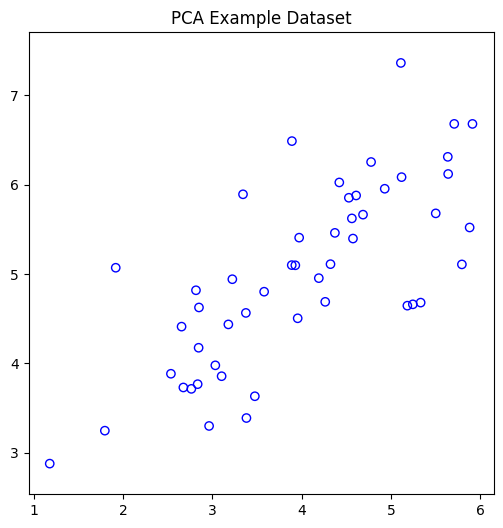

In [ ]:
# Task 3: Load PCA Dataset
!wget https://github.com/dibgerge/ml-coursera-python-assignments/raw/master/Exercise7/Data/ex7data1.mat -O ex7data1.mat

pca_data = loadmat('ex7data1.mat')
X_pca = pca_data['X']

def normalize_features(X):
    #Normalizes features to have zero mean and unit variance.
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = normalize_features(X_pca)

plt.figure(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], edgecolors='b', facecolors='none')
plt.title("PCA Example Dataset")
plt.axis('equal')
plt.show()

In [ ]:
def pca(X):
    #Computes the principal components of the dataset X.
    m = X.shape[0]
    # Compute Covariance Matrix
    sigma_matrix = (1 / m) * (X.T @ X)
    # Run SVD
    U, S, V = np.linalg.svd(sigma_matrix)
    return U, S

# Run PCA
U, S = pca(X_norm)

print("Top Principal Component (U[:, 0]):")
print(U[:, 0])

Top Principal Component (U[:, 0]):
[-0.70710678 -0.70710678]


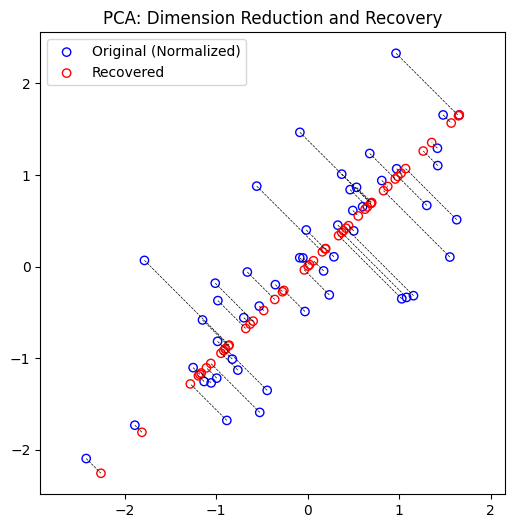

In [ ]:
def project_data(X, U, K):
    #Projects data onto the first K principal components.
    U_reduce = U[:, :K]
    return X @ U_reduce

def recover_data(Z, U, K):
    #Recovers an approximation of the original data from projected data.
    U_reduce = U[:, :K]
    return Z @ U_reduce.T

# Project onto K=1 dimension
K_dim = 1
Z = project_data(X_norm, U, K_dim)
X_rec = recover_data(Z, U, K_dim)

# Visualize Reconstruction
plt.figure(figsize=(6, 6))
plt.scatter(X_norm[:, 0], X_norm[:, 1], edgecolors='b', facecolors='none', label='Original (Normalized)')
plt.scatter(X_rec[:, 0], X_rec[:, 1], edgecolors='r', facecolors='none', label='Recovered')
for i in range(X_norm.shape[0]):
    plt.plot([X_norm[i,0], X_rec[i,0]], [X_norm[i,1], X_rec[i,1]], 'k--', lw=0.5)

plt.title("PCA: Dimension Reduction and Recovery")
plt.legend()
plt.axis('equal')
plt.show()